## Procesos de Markov

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

# Crear el entorno CartPole. Este es el MDP.
env = gym.make('CartPole-v1')
n_acciones = env.action_space.n # 2 acciones: 0 (empujar izquierda) o 1 (empujar derecha)

print(f"Acciones disponibles: {n_acciones}")
print("El estado es continuo, por lo que se requiere discretización.")

Acciones disponibles: 2
El estado es continuo, por lo que se requiere discretización.


In [33]:
# =======================================================
# Definición de Bins (Contenedores) para Discretización
# =======================================================

# Definimos el número de bins para cada una de las 4 variables de estado
# Esto resulta en 10 x 10 x 10 x 10 = 10,000 estados discretos.
n_bins = (10, 10, 10, 10) 
n_estados_discretos = np.prod(n_bins)

# Definición de los límites de los bins usando np.linspace:
posicion_bins = np.linspace(-4.8, 4.8, n_bins[0] - 1)
velocidad_bins = np.linspace(-4.0, 4.0, n_bins[1] - 1) 
angulo_bins = np.linspace(-0.418, 0.418, n_bins[2] - 1) # ~24 grados, límite de fallo
vel_angular_bins = np.linspace(-4.0, 4.0, n_bins[3] - 1) 

# Lista de límites que se pasará a la función de discretización
limites_bins = [posicion_bins, velocidad_bins, angulo_bins, vel_angular_bins]

print(f"Tamaño total del Espacio de Estado Discretizado: {n_estados_discretos} estados")

# =============================================================================
# Función de Discretización
# =============================================================================

def discretize_state(estado_continuo, limites_bins):
    """
    Convierte el array de estado continuo (4 valores) en un índice discreto único.
    """
    # 1. Asignar cada valor continuo a su bin (índice)
    discretized = [np.digitize(estado_continuo[i], limites_bins[i]) for i in range(len(estado_continuo))]
    
    # 2. Mapeo lineal a un índice único para la Tabla Q
    discrete_state_index = discretized[0] * n_bins[1] * n_bins[2] * n_bins[3] + \
                           discretized[1] * n_bins[2] * n_bins[3] + \
                           discretized[2] * n_bins[3] + \
                           discretized[3]
                           
    return discrete_state_index

Tamaño total del Espacio de Estado Discretizado: 10000 estados


In [34]:
# =============================================================================
# 3. Inicialización de la Tabla Q y Parámetros
# =============================================================================

# Inicialización de la Tabla Q: [Total de Estados Discretos, Total de Acciones]
Q = np.zeros((n_estados_discretos, n_acciones))

# Parámetros de Q-Learning (Hiperparámetros)
episodios = 20000
alpha = 0.1       # Tasa de aprendizaje (Learning rate)
gamma = 0.99      # Factor de descuento (Determina cuánto se valora la recompensa futura)
epsilon = 1.0     # Probabilidad inicial de exploración
epsilon_min = 0.01
epsilon_decay = 0.9995

historial_recompensas = []

print(f"Tabla Q inicializada con {Q.shape[0]} estados y {Q.shape[1]} acciones.")
print("Hiperparámetros de Q-learning definidos.")

Tabla Q inicializada con 10000 estados y 2 acciones.
Hiperparámetros de Q-learning definidos.


In [35]:
# =============================================================================
# 4. Entrenamiento (Aplicación del Modelo de Markov - Q-learning)
# =============================================================================

print("Iniciando Entrenamiento Q-LEARNING para CartPole...\n")

for ep in range(episodios):
    estado_continuo, _ = env.reset() 
    estado = discretize_state(estado_continuo, limites_bins)
    
    recompensa_total = 0
    done = False
    truncated = False
    
    while not done and not truncated:
        
        # 1. Política Epsilon-greedy (Exploración vs. Explotación)
        if np.random.random() < epsilon:
            accion = env.action_space.sample()  # Exploración 
        else:
            accion = np.argmax(Q[estado])      # Explotación (mejor acción aprendida)
        
        # 2. Ejecutar la acción y obtener el nuevo estado continuo y recompensa
        nuevo_estado_continuo, recompensa, done, truncated, _ = env.step(accion)
        
        # 3. Discretizar el nuevo estado
        nuevo_estado = discretize_state(nuevo_estado_continuo, limites_bins)
        
        # 4. Actualización Q-learning (Ecuación de Bellman de Optimidad)
        Q[estado, accion] += alpha * (recompensa + gamma * np.max(Q[nuevo_estado]) - Q[estado, accion])
        
        estado = nuevo_estado
        recompensa_total += recompensa
        
    historial_recompensas.append(recompensa_total)
    
    # 5. Decaimiento del Epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    
    # Mostrar progreso
    if (ep + 1) % 5000 == 0:
        media = np.mean(historial_recompensas[-100:])
        print(f"Episodio {ep+1}/{episodios} | Recompensa media (últimos 100): {media:.1f} | Epsilon: {epsilon:.4f}")

print("\nEntrenamiento finalizado. La Tabla Q contiene la política aprendida.")

Iniciando Entrenamiento Q-LEARNING para CartPole...

Episodio 5000/20000 | Recompensa media (últimos 100): 231.0 | Epsilon: 0.0820
Episodio 10000/20000 | Recompensa media (últimos 100): 202.2 | Epsilon: 0.0100
Episodio 15000/20000 | Recompensa media (últimos 100): 255.4 | Epsilon: 0.0100
Episodio 20000/20000 | Recompensa media (últimos 100): 492.4 | Epsilon: 0.0100

Entrenamiento finalizado. La Tabla Q contiene la política aprendida.


In [36]:
# =============================================================================
# 5. Evaluación de la Política Aprendida
# =============================================================================

def evaluate_agent(Q_table, n_tests=100):
    """
    Evalúa la Tabla Q final sin ninguna exploración.
    """
    env_eval = gym.make('CartPole-v1')
    recompensas_test = []
    
    for _ in range(n_tests):
        estado_continuo, _ = env_eval.reset()
        estado = discretize_state(estado_continuo, limites_bins)
        recompensa_total = 0
        done = False
        truncated = False
        
        # Límite de pasos del entorno es 500
        for _ in range(500): 
            if done or truncated:
                break
            
            # Explotación pura (elegir la mejor acción aprendida)
            accion = np.argmax(Q_table[estado])
            nuevo_estado_continuo, recompensa, done, truncated, _ = env_eval.step(accion)
            estado = discretize_state(nuevo_estado_continuo, limites_bins)
            recompensa_total += recompensa
            
        recompensas_test.append(recompensa_total)
    
    env_eval.close()
    
    # CartPole se considera resuelto si se mantiene cerca del límite máximo de 500
    exitos = sum(r >= 475 for r in recompensas_test)
    
    print("\nRESULTADOS FINALES DE LA EVALUACIÓN:")
    print(f"✓ Recompensa media en {n_tests} pruebas: {np.mean(recompensas_test):.2f}")
    print(f"✓ Desviación estándar de recompensa: {np.std(recompensas_test):.2f}")
    print(f"✓ Intentos exitosos (puntuación >= 475): {exitos}/{n_tests}")

# Ejecutar la evaluación
evaluate_agent(Q, n_tests=100)


RESULTADOS FINALES DE LA EVALUACIÓN:
✓ Recompensa media en 100 pruebas: 495.09
✓ Desviación estándar de recompensa: 48.85
✓ Intentos exitosos (puntuación >= 475): 99/100


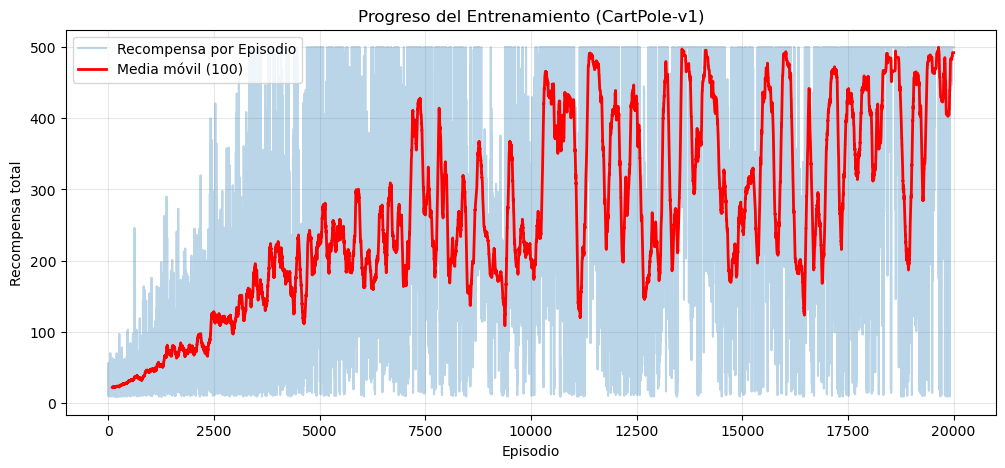

In [37]:
# =============================================================================
# 6. Visualización de la Curva de Aprendizaje
# =============================================================================

plt.figure(figsize=(12, 5))
plt.plot(historial_recompensas, alpha=0.3, label='Recompensa por Episodio')

ventana = 100
if len(historial_recompensas) >= ventana:
    # Media móvil para suavizar la curva y ver la tendencia de aprendizaje
    media_movil = np.convolve(historial_recompensas, np.ones(ventana)/ventana, mode='valid')
    plt.plot(range(ventana-1, len(historial_recompensas)), media_movil, 'r-', linewidth=2, label=f'Media móvil ({ventana})')

plt.xlabel('Episodio')
plt.ylabel('Recompensa total')
plt.title('Progreso del Entrenamiento (CartPole-v1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [42]:
import time

# Crear el entorno con modo de renderizado visual
env_visual = gym.make('CartPole-v1', render_mode='human')
estado_continuo, _ = env_visual.reset()
estado = discretize_state(estado_continuo, limites_bins)

print("Iniciando demostración visual de la política aprendida (Explotación pura)...")
print("Cierre la ventana gráfica para terminar la ejecución.")

done = False
truncated = False

for paso in range(1000): # Límite máximo de pasos
    if done or truncated:
        break
        
    # Explotación pura: Elegir la acción con el mayor valor Q para el estado actual
    accion = np.argmax(Q[estado])
    
    # Ejecutar el paso
    nuevo_estado_continuo, _, done, truncated, _ = env_visual.step(accion)
    estado = discretize_state(nuevo_estado_continuo, limites_bins)
    
    # Pausa breve para que el ojo humano pueda ver el movimiento
    time.sleep(0.02) 
    
if not done and not truncated:
    print(f"Éxito: El agente alcanzó el límite máximo de 500 pasos.")
elif done or truncated:
    print(f"Finalizado en {paso+1} pasos. (Péndulo caído o límites excedidos).")

env_visual.close()

Iniciando demostración visual de la política aprendida (Explotación pura)...
Cierre la ventana gráfica para terminar la ejecución.
Finalizado en 501 pasos. (Péndulo caído o límites excedidos).


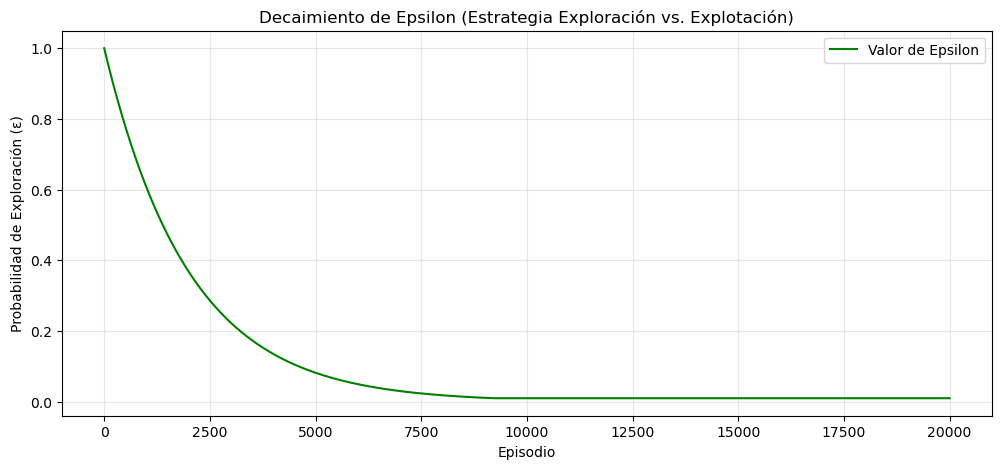

In [39]:
# =============================================================================
# 4. Generación de Gráfica de Decaimiento Epsilon
# =============================================================================

# Recalculamos el historial de epsilon si la variable no se guardó durante el entrenamiento
epsilon_historial = []
ep_val = 1.0 
for _ in range(episodios):
    ep_val = max(epsilon_min, ep_val * epsilon_decay)
    epsilon_historial.append(ep_val)

plt.figure(figsize=(12, 5))
plt.plot(epsilon_historial, label='Valor de Epsilon', color='green')
plt.xlabel('Episodio')
plt.ylabel('Probabilidad de Exploración (ε)')
plt.title('Decaimiento de Epsilon (Estrategia Exploración vs. Explotación)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()